In [2]:
import os
from openai import OpenAI
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

import numpy as np
# from scipy.interpolate import RegularGridInterpolator
import pandas as pd
import matplotlib.pyplot as plt

import json
import io
import inspect
import requests
import ChatAPICallFunctionsLib as cfl
import AutoSTMFuctionsLib as stmfl

In [3]:
functions_dict_path = 'toolsjsdict.json'
with open(functions_dict_path, 'r') as file:
    toolsjsdict = json.load(file)


tools_list = [stmfl.load_txt_from_idl,stmfl.plot_topo,stmfl.polybackRow,stmfl.plot_fft,stmfl.fftamp]
files_to_load = ['06_10_24_002.txt','06_15_24_010.txt','06_16_24_006.txt']

In [4]:
image_pool = []
messages = [
        {"role": "system", "content": "The path to load data is %s, the fils to load under this path are %s" % ('Data', files_to_load)},
        {"role": "user", "content": 'load the txt file from given path and convert it into numpy array'}]

In [6]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool)},
        {"role": "user", "content": 'please use the plot function to plot all the arrays as topography images'}]


In [10]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_polyback_2)},
        {"role": "user", "content": 'please use the plot function to plot all the arrays as topography images'}]

In [14]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_FFT_Amp)},
        {"role": "user", "content": 'please use the plot_fft function to plot all the arrays as Fourier transform images, with histgram range: hist = %s' %(['0','30'])}]

In [8]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool)},
        {"role": "user", "content": 'please apply polybackRow function on all the arrays with polyord = %s' %('2')}]


In [12]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_polyback_2)},
        {"role": "user", "content": 'please apply fftamp function on all the arrays to get their Fourier transform'}]

Excuted function: [plot_fft] with arguments: {"data_name": "x06_10_24_002_polyback_2_FFT_Amp", "hist": ["0", "30"]}


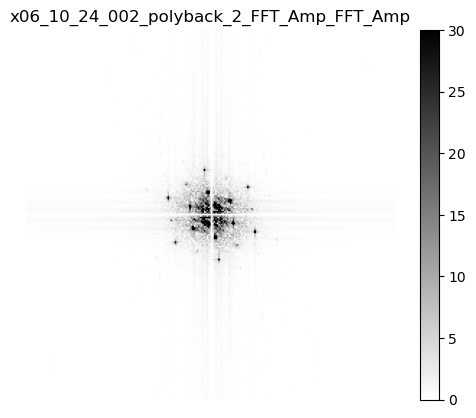

Excuted function: [plot_fft] with arguments: {"data_name": "x06_15_24_010_polyback_2_FFT_Amp", "hist": ["0", "30"]}


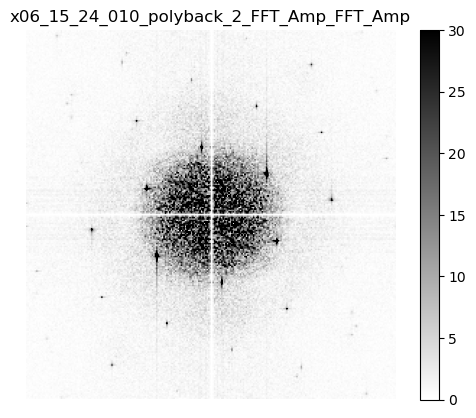

Excuted function: [plot_fft] with arguments: {"data_name": "x06_16_24_006_polyback_2_FFT_Amp", "hist": ["0", "30"]}


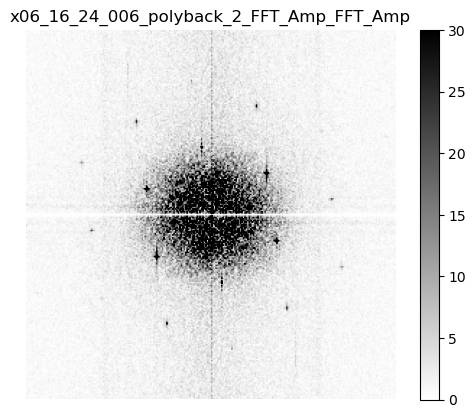

In [15]:
cfl.run_conversation1(messages = messages, tools_list = tools_list, toolsjsdict = toolsjsdict, global_namespace=globals())

In [ ]:
# model = 'gpt-4o'
# response = client.chat.completions.create(
#                 model="gpt-4o",
#                 messages=messages,
#                 tools=toolsjsdict,
#                 tool_choice="auto")
# response_message = response.choices[0].message.tool_calls
# print(response_message)

In [24]:
test_array = x06_15_24_010

In [10]:
e = np.array([13,15])
s = np.array([2,3])
ams = e-s
ams

array([11, 12])

In [15]:
def extract_linecut(data_name,sx_str,sy_str,ex_str,ey_str,avgT_str,avgL_str,global_namespace=None):
    global_namespace = globals()
    data = global_namespace[data_name]
    sx = int(sx_str)
    sy = int(sy_str)
    ex = int(ex_str)
    ey = int(ey_str)
    avgL = int(avgL_str)
    avgT = int(avgT_str)
    N = -1
    
    startcen = np.array([sx,sy])
    endcen = np.array([ex,ey])
    
    if startcen[0] == endcen[0]:
        ang = 90
    elif startcen[1] == endcen[1]:
        ang = 0
    else: 
        diff = endcen - startcen
        ang = np.arctan(diff[1]/diff[0])
        if ang < 0:
            ang = ang + np.pi
    
    deltaX = np.sin(ang)
    deltaY = np.cos(ang)
    
    if ang >= 90:
        deltaUp = np.array([deltaX, -deltaY])
    else:
        deltaUp = np.array([-deltaX,deltaY])
    
    starttop = startcen + (avgT-1)/2 * deltaUp
    endtop = endcen + (avgT-1)/2 * deltaUp
    
    N = np.round(linelength) + 1
    
    linelength = np.sqrt(np.sum((endcen-startcen)**2)) 
    
    step = ()
    
    alldata = 
    
    for i in range(0,avgT):
        startpos = starttop - i * deltaUp
        endpos = endtop - i * deltaUp
        

array([[1, 2, 3],
       [4, 5, 6]])

[-0.61545608 -0.13970775 -0.66068448]


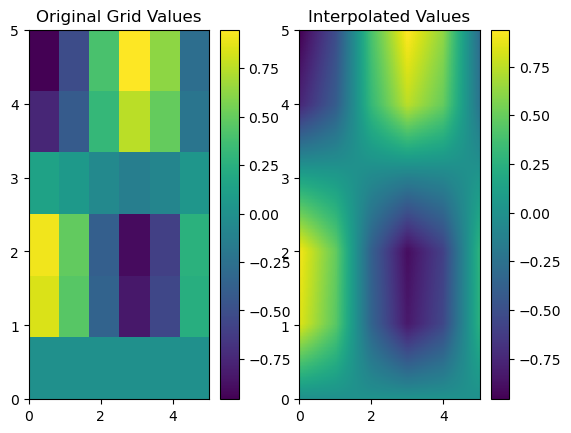

In [5]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import matplotlib.pyplot as plt

# Define the grid points
x = np.linspace(0, 5, 6)  # 6 points from 0 to 5
y = np.linspace(0, 5, 6)  # 6 points from 0 to 5

# Create a meshgrid of x and y (this represents a grid of coordinates)
X, Y = np.meshgrid(x, y, indexing='ij')

# Define the function values at the grid points
# For example, f(x, y) = sin(x) * cos(y)
values = np.sin(X) * np.cos(Y)

# Create the RegularGridInterpolator object
interpolator = RegularGridInterpolator((x, y), values)

# Define new points where you want to interpolate
new_points = np.array([[1.5, 2.5], [3.0, 3.0], [4.5, 0.5]])

# Interpolate at those points
interpolated_values = interpolator(new_points)
print(interpolated_values)

# Define a finer grid for visualization
x_fine = np.linspace(0, 5, 100)
y_fine = np.linspace(0, 5, 100)

# Create a meshgrid for the finer grid
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# Flatten the meshgrid points for interpolation
fine_points = np.array([X_fine.ravel(), Y_fine.ravel()]).T

# Interpolate at the finer grid points
fine_values = interpolator(fine_points).reshape(100, 100)

# Plot the original grid points and interpolated surface
plt.subplot(121)
plt.title("Original Grid Values")
plt.imshow(values, extent=(0, 5, 0, 5), origin='lower', aspect='auto', cmap='viridis')
plt.colorbar()

plt.subplot(122)
plt.title("Interpolated Values")
plt.imshow(fine_values, extent=(0, 5, 0, 5), origin='lower', aspect='auto', cmap='viridis')
plt.colorbar()

plt.show()


In [21]:
import numpy as np

# Create two 2D arrays
array1 = np.array([[1, 2, 3], [4, 5, 6]])
array2 = np.array([[7, 8, 9], [10, 11, 12]])
array3 = np.random.rand(2, 3)

# Stack the arrays along a new axis
stacked_array = np.concatenate((array1, np.expand_dims(array2, axis=0)), axis=0)

# Expand dimensions of stacked_array to match array3
stacked_array = np.concatenate((stacked_array, np.expand_dims(array3, axis=0)), axis=0)

print("Stacked array shape:", stacked_array.shape)
print(stacked_array)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 3 dimension(s)